In [1]:
%load_ext autoreload
%autoreload 2

from seek_code import SEEK
from data_handler import EleHandler
from classifier import Classifier
from backbone import Backbone
from concept_head import ConceptHead
from retrieval import Retrieval
from projector import Projector

from torch.utils.data import DataLoader, Subset
from torch.utils.data.sampler import RandomSampler
from torch.utils.data import DataLoader, SequentialSampler

import torch, math
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import random
import torch.nn.functional as F

/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = EleHandler(subset='IDI_6')
train_indices, test_indices = dataset.split_perpendicular_to_elephants_and_encounters(split_sizes=[0.5,0.5], hour_delta = 0.2)

# Check if train and test indices intersect
print("Intersection of train and test indices:", set(train_indices) & set(test_indices))

train_subset = Subset(dataset, train_indices)
test_subset = Subset(dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=512, shuffle=False)

Intersection of train and test indices: set()


# Baseline 1

In [3]:
code = 'baseline-1-MD-debug'
r11 = Retrieval(experiment_code=code)

MD = Backbone(with_ears = True, pretraining = "savannah-elephants", experiment_code=code)
r11.evaluate_model(MD, train_loader, test_loader, show_plot=False,show_matches=False,show_tsne=False)

evaluating backbone
Train Recalls:
Recall@1: 5.40%
Recall@5: 11.81%
Recall@10: 16.96%
Recall@20: 23.78%
Recall@100: 49.22%
Test Recalls:
Recall@1: 19.19%
Recall@5: 31.76%
Recall@10: 39.15%
Recall@20: 46.76%
Recall@100: 72.89%


## Baseline-2 : finetuning

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Backbone parameters require gradients: True
Epoch 1/5 - Train Loss: 6.9254, BATCH-Recall@1: 0.86%, --- EPOCH - Recall@1: 6.41%, Recall@5: 11.31%, Recall@20: 21.45%, Recall@100: 44.52%
Epoch 2/5 - Train Loss: 6.1470, BATCH-Recall@1: 0.71%, --- EPOCH - Recall@1: 7.57%, Recall@5: 14.29%, Recall@20: 23.88%, Recall@100: 47.20%
Epoch 3/5 - Train Loss: 5.4965, BATCH-Recall@1: 0.86%, --- EPOCH - Recall@1: 9.54%, Recall@5: 17.42%, Recall@20: 30.19%, Recall@100: 55.33%
Epoch 4/5 - Train Loss: 4.3275, BATCH-Recall@1: 1.46%, --- EPOCH - Recall@1: 13.12%, Recall@5: 23.57%, Recall@20: 38.41%, Recall@100: 64.92%
Epoch 5/5 - Train Loss: 3.0368, BATCH-Recall@1: 0.91%, --- EPOCH - Recall@1: 17.77%, Recall@5: 33.82%, Recall@20: 51.24%, Recall@100: 75.47%
evaluating backbone
Train Recalls:
Recall@1: 17.77%
Recall@5: 33.82%
Recall@10: 41.90%
Recall@20: 51.24%
Recall@100: 75.47%
Test Recalls:
Recall@1: 27.27%
Recall@5: 40.21%
Recall@10: 46.08%
Recall@20: 55.45%
Recall@100: 78.83%


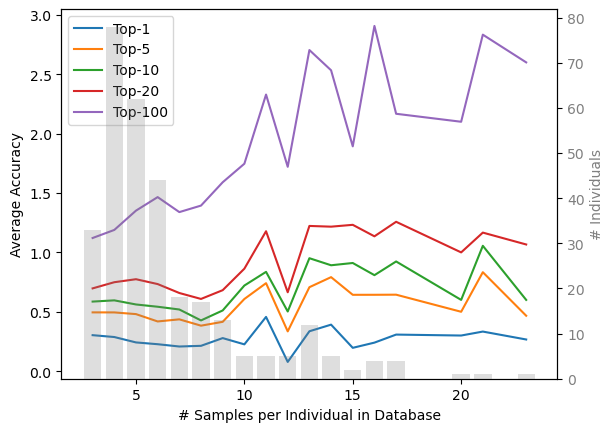

In [ ]:
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=True)

code = 'baseline-2-MD-debug'
r21 = Retrieval(experiment_code=code)

MD = Backbone(with_ears = True, lr = 1e-4, pretraining = "savannah_elephants", experiment_code=code)
MD.train(train_loader, val_loader=train_loader, num_epochs=5)

r21.evaluate_model(MD, train_loader, test_loader, show_matches=False, show_tsne=False)

# Unitary test : fine-tuning using the projector architecture

In [ ]:
code = 'chair-debug'
ba = Backbone(pretraining='savannah_elephants', experiment_code=code)

ch = ConceptHead(experiment_code=code)
ch.test(train_loader,ba)
ch.freeze()

r = Retrieval(experiment_code=code)
pr = Projector(criterion = 'ArcFace', lr = 0.0001, scale = 64, margin = 0.5, experiment_code=code)

ba.unfreeze()
ch.freeze()
pr.freeze()

pr.train(train_loader, train_loader, ba, ch, num_epochs=5)

r.evaluate_model(pr, train_loader, test_loader, ba, ch, show_matches=False, show_tsne=False, show_plot=False)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

ConceptHead - Test Loss: 0.0607, Test Accuracy: 86.37%
sex Accuracy: 96.47%
age Accuracy: 97.83%
right_tusk Accuracy: 87.48%
left_tusk Accuracy: 88.33%
R_tear_1 Accuracy: 73.90%
R_hole_1 Accuracy: 82.19%
R_tear_2 Accuracy: 78.35%
R_hole_2 Accuracy: 87.74%
L_tear_1 Accuracy: 72.08%
L_hole_1 Accuracy: 83.24%
L_tear_2 Accuracy: 77.63%
L_hole_2 Accuracy: 87.37%
right_extreme Accuracy: 91.82%
left_extreme Accuracy: 89.45%
ear_special Accuracy: 93.18%
body_special Accuracy: 94.85%
average Accuracy: 86.37%
whole_code Accuracy: 37.25%


Ok so, my goal was to run a fine-tuning of the backbone through the projector architecture.

I learnt a lot. Things were not working how I was expecting them to be :
- The backbone is not learning through the projector train function
- It comes from the fact that its weights are not included in the optimizer

The next step should be the following : 
- inclue them in the optimizer
- test that I can finetune by using the Project.train()
- Try to understand why the projector is not learning (all this does not justify the decrease in recall)



ok great !

# My goal is that this works, training the projector only

In [10]:
code = 'debug'
ch = ConceptHead(experiment_code=code)
ba = Backbone(pretraining='savannah_elephants', experiment_code=code)

r = Retrieval(experiment_code=code)
pr = Projector(criterion = 'ArcFace', lr = 0.0001, scale = 64, margin = 0.5, experiment_code=code)

ba.freeze()
ch.freeze()
pr.unfreeze()

pr.train(train_loader, train_loader, ba, ch, num_epochs=5)

r.evaluate_model(pr, train_loader, test_loader, ba, ch, show_matches=False, show_tsne=False, show_plot=False)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Concept head parameters require gradients: False 
Backbone parameters require gradients: False 
Projector parameters require gradients: True
Hard predicted concepts: B00T11E9000-0000X00S00
ele_id_label: tensor([  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
          6,   6,   6,   6,   6,   6,   7,   7,   7,   7,   7,   7,   7,   7,
          7,   7,   7,   7,   7,   7,   7,   7,   3,   3,   3,   3,   8,   8,
          8,   8,   8,   8,   8,   4,   4,   4,   4,   4,   4,   4,   4,   4,
          4,   4,   4,   4,   4,   4,   2,   2,   2,   2,   2,   2,   2,   2,
          2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,   2,
          2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   5,   5,   5,   5,  10,  10,
         10,  10,  10,  10,  10,  10,  10,  10,  10,  10,  10,  11,  11,  11,
         11,  11,  26,  26,  26,  26,  26,  26,  25,  25,  25,  25,  25,  25,
         25,  25,

KeyboardInterrupt: 

## It still does not work. Maybe, the concept extracted are really bad and not really helping. So I will try projecting the ground-truth SEEK codes

In [8]:
def perfect_correction(hard_predicted_concepts, subject_SEEK, elephant_SEEK):
    return subject_SEEK

def oracle_correction(hard_predicted_concepts, subject_SEEK, elephant_SEEK):
    return elephant_SEEK

In [ ]:
code = 'debug'
ch = ConceptHead(experiment_code=code)
ba = Backbone(pretraining='savannah_elephants', experiment_code=code)

r = Retrieval(experiment_code=code)
pr = Projector(criterion = 'ArcFace', lr = 0.0001, scale = 64, margin = 0.5, experiment_code=code)

ba.freeze()
ch.freeze()
pr.unfreeze()

pr.train(train_loader, train_loader, ba, ch, num_epochs=5, intervention_fn=None)

r.evaluate_model(pr, train_loader, test_loader, ba, ch, show_matches=False, show_tsne=False, show_plot=False)

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

Concept head parameters require gradients: False 
Backbone parameters require gradients: False 
Projector parameters require gradients: True
Epoch 1/5 - Train Loss: 7.0863, BATCH-Recall@1: 0.96%, --- EPOCH - Recall@1: 6.61%, Recall@5: 12.22%, Recall@20: 21.86%, Recall@100: 46.44%
Epoch 2/5 - Train Loss: 6.9067, BATCH-Recall@1: 0.96%, --- EPOCH - Recall@1: 6.61%, Recall@5: 12.32%, Recall@20: 21.91%, Recall@100: 46.24%
Epoch 3/5 - Train Loss: 6.7710, BATCH-Recall@1: 1.11%, --- EPOCH - Recall@1: 6.51%, Recall@5: 12.32%, Recall@20: 21.86%, Recall@100: 46.04%
Epoch 4/5 - Train Loss: 6.6518, BATCH-Recall@1: 0.76%, --- EPOCH - Recall@1: 6.51%, Recall@5: 12.17%, Recall@20: 21.86%, Recall@100: 46.09%


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")


Epoch 5/5 - Train Loss: 6.5453, BATCH-Recall@1: 1.12%, --- EPOCH - Recall@1: 6.51%, Recall@5: 12.27%, Recall@20: 21.81%, Recall@100: 46.09%


batch_recall@1,▅▅█▁█
epoch,▁▃▅▆█
epoch_recall@1,██▁▁▁
epoch_recall@100,█▅▁▂▂
epoch_recall@20,▄█▄▄▁
epoch_recall@5,▃██▁▆
train_loss,█▆▄▂▁
batch_recall@1,1.11879
epoch,5
epoch_recall@1,6.51186
epoch_recall@100,46.08783


evaluating projector
Train Recalls:
Recall@1: 6.51%
Recall@5: 12.27%
Recall@10: 15.70%
Recall@20: 21.81%
Recall@100: 46.09%
Test Recalls:
Recall@1: 19.04%
Recall@5: 30.39%
Recall@10: 35.34%
Recall@20: 42.04%
Recall@100: 63.98%


## It seems that we either have a bug in the projector training OR the SEEK codes are useless for 
## I will try retrieving from the concepts only (CBM) with predicted concepts, ground-truth concepts and oracle concepts (elephant-level) 

In [9]:
#  Retrieval from extacted concepts
code = 'debug'
MD = Backbone(with_ears = True, lr = 1e-4, pretraining = "savannah_elephants", experiment_code=code)
ch1 = ConceptHead(experiment_code=code)
ch1.test(test_loader,MD)
cbm_r = Retrieval(experiment_code='debug')
cbm_r.evaluate_model(ch1, train_loader, test_loader, ba = MD, show_matches=False, show_tsne=False, show_plot=False)

ConceptHead - Test Loss: 0.0699, Test Accuracy: 84.18%
sex Accuracy: 95.35%
age Accuracy: 96.64%
right_tusk Accuracy: 85.53%
left_tusk Accuracy: 86.47%
R_tear_1 Accuracy: 68.77%
R_hole_1 Accuracy: 80.18%
R_tear_2 Accuracy: 74.60%
R_hole_2 Accuracy: 86.68%
L_tear_1 Accuracy: 67.58%
L_hole_1 Accuracy: 79.85%
L_tear_2 Accuracy: 75.10%
L_hole_2 Accuracy: 85.65%
right_extreme Accuracy: 90.23%
left_extreme Accuracy: 89.84%
ear_special Accuracy: 91.16%
body_special Accuracy: 93.31%
average Accuracy: 84.18%
whole_code Accuracy: 35.63%
evaluating concept head  
collecting concepts from concept head


100%|██████████| 4/4 [00:13<00:00,  3.42s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:08<00:00,  2.95s/it]


Train Recalls:
Recall@1: 1.92%
Recall@5: 6.11%
Recall@10: 9.34%
Recall@20: 15.19%
Recall@100: 41.54%
Test Recalls:
Recall@1: 2.89%
Recall@5: 7.08%
Recall@10: 11.81%
Recall@20: 18.13%
Recall@100: 46.31%


evaluating concept head   with intervention
collecting concepts from concept head


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:13<00:00,  3.29s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:08<00:00,  2.77s/it]


Train Recalls:
Recall@1: 3.89%
Recall@5: 10.35%
Recall@10: 16.36%
Recall@20: 23.57%
Recall@100: 49.57%
Test Recalls:
Recall@1: 5.03%
Recall@5: 13.02%
Recall@10: 19.42%
Recall@20: 28.41%
Recall@100: 58.87%


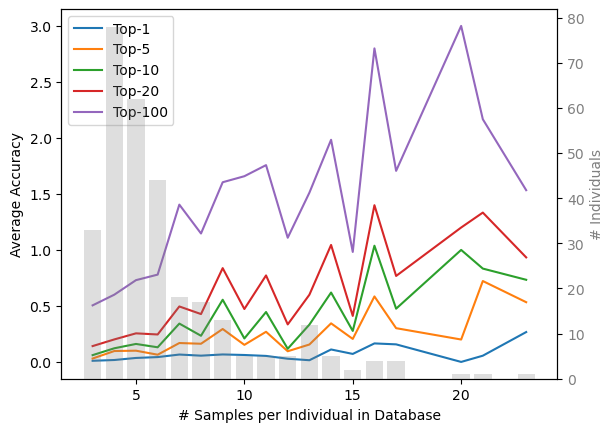

In [10]:
#  Retrieval from extacted concepts
cbm_r.evaluate_model(ch1, train_loader, test_loader, ba = MD, show_matches=False, show_tsne=False, intervention_fn=perfect_correction)

evaluating concept head   with intervention
collecting concepts from concept head


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:13<00:00,  3.28s/it]


collecting concepts from concept head


100%|██████████| 3/3 [00:08<00:00,  2.81s/it]


Train Recalls:
Recall@1: 83.34%
Recall@5: 84.81%
Recall@10: 89.45%
Recall@20: 96.87%
Recall@100: 100.00%
Test Recalls:
Recall@1: 83.09%
Recall@5: 84.84%
Recall@10: 89.19%
Recall@20: 96.57%
Recall@100: 100.00%


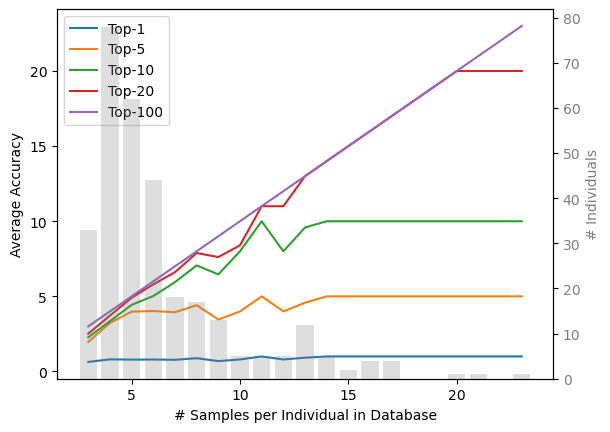

In [11]:
# Performing retrieval with oracle correction, i.e. using the true labels
cbm_r.evaluate_model(ch1, train_loader, test_loader, ba = MD, show_matches=False, show_tsne=False, intervention_fn=oracle_correction)

## Ok this is a big deal. It shows that :
    1. Although the concept head acheives a test-accuracy of 85% seems pretty good, the 15% error divides by 3 the predictive quality of the concepts
    2. There is a huge gap between subject SEEK and and elephant_SEEK in predictive capabilities (4.57% vs 81.65%) 

## Directions : 
    1. I want to try learning the projector using elephant_SEEK to see if it could actually improve the geometry of the embedding space (proof of concept)
    2. I need to see if we are making systematic errors in the concept head
    3. I need to see if we can directly learn elephant SEEK instead of subject SEEK


## Learning a projector from corrected oracle corrected concepts (elephant-level concepts) 
when training with a batch size of 64, it seems to be learning to improve recall within batches, while decreasing general train recall.  

In [14]:
train_loader = DataLoader(train_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

ch = ConceptHead(experiment_code='debug')
ba = Backbone(pretraining='savannah_elephants', experiment_code=code)

r = Retrieval(experiment_code=code)

pr = Projector(criterion = 'ArcFace', lr = 0.001, scale = 64, margin = 0.5, experiment_code=code)

ba.freeze()
ch.freeze()
pr.unfreeze()

pr.train(train_loader, test_loader, ba, ch, num_epochs=150, intervention_fn=oracle_correction)

print('evaluation under oracle correction')
r.evaluate_model(pr, train_loader, test_loader, ba, ch, show_matches=False, show_tsne=False, show_plot=False, intervention_fn=oracle_correction)
print('evaluation under perfect subject correction')
r.evaluate_model(pr, train_loader, test_loader, ba, ch, show_matches=False, show_tsne=False, show_plot=False, intervention_fn=perfect_correction)
print('evaluation under no correction')
r.evaluate_model(pr, train_loader, test_loader, ba, ch, show_matches=False, show_tsne=False, show_plot=False, intervention_fn=None)

Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x7fda70102850>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7fda34a47c40, raw_cell="train_loader = DataLoader(train_subset, batch_size.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Bbeery-a100-2csailmit/data/vision/beery/scratch/antoine/CBM_reid/methods/debug-projector.ipynb#X32sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

/data/vision/beery/scratch/antoine/CBM_reid/methods/backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weight_path, map_location=self.devi

BrokenPipeError: [Errno 32] Broken pipe

Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x7fda70102850>> (for post_run_cell), with arguments args (<ExecutionResult object at 7fda355c95b0, execution_count=14 error_before_exec=None error_in_exec=[Errno 32] Broken pipe info=<ExecutionInfo object at 7fda34a47c40, raw_cell="train_loader = DataLoader(train_subset, batch_size.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://tunnel%2Bbeery-a100-2csailmit/data/vision/beery/scratch/antoine/CBM_reid/methods/debug-projector.ipynb#X32sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

# Several things :
    1. We manage to train the projector showing the projector to much higher accuracies. Showing that the problem was the prior
    2. Do we beat the baseline of the CBM ? Yes/No -> We surpass CBM
    3. Do we improve retrieval under no correction ? Do we care for now ?
    4. We have to direct our efforts to better concept predition
    5. The potential increase in recall@1 is huge. Jumping from 33% to >70% !!

## How to improve concept predictions ? Several strategies :
    1. Cheat and use corrected corrected or oracle concepts (what we did above)
    2. Train longer on fine-tuned embeddings 
    3. Aggregate the subject SEEK into ele_SEEK at evaluation time ? Is it relevant ??? Is it realistic to do it in the Gallery ? in the query set ? Within the same encounter only in the query set ?


## Before doing this ? I feel like there is somthing wrong within my data. Let me have a look at it.

In [4]:

dataset = EleHandler(subset='IDI_6')

batch_id = 0
image_id = random.randint(0, 63)

## Show what is inside 
for i, batch in enumerate(train_loader):
    if i == batch_id:
        preprocessed_image, subject_id, ele_id_label, identified, subject_SEEK_1hot, ele_SEEK_1hot, left_ear, right_ear, subject_SEEK, ele_SEEK, idx = batch

        print('idx', idx[image_id])
        print('subject_id', int(subject_id[image_id]))
        print('ele_id_label', ele_id_label[image_id])
        print('subject_SEEK_1hot', SEEK(subject_SEEK_1hot[image_id]))
        print('subject_SEEK', SEEK(subject_SEEK[image_id]))
        print('ele_SEEK', SEEK(ele_SEEK[image_id]))
        print('ele_SEEK_1hot', SEEK(ele_SEEK_1hot[image_id]))
        #print('preprocessed_image', preprocessed_image[image_id])
        #print('left_ear', left_ear[image_id])
        #print('right_ear', right_ear[image_id])

        # Display the images
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(preprocessed_image[image_id].permute(1, 2, 0))
        axes[0].set_title('Preprocessed Image')
        axes[1].imshow(left_ear[image_id].permute(1, 2, 0))
        axes[1].set_title('Left Ear')
        axes[2].imshow(right_ear[image_id].permute(1, 2, 0))
        axes[2].set_title('Right Ear')
        for ax in axes:
            ax.axis('off')
        plt.show()

        dataset.print_image(idx=int(idx[image_id]))

        break


RuntimeError: stack expects each tensor to be equal size, but got [3, 224, 224] at entry 0 and [3, 929, 777] at entry 1

## As I thought, the model is mixing left and right ears, let's fix this 